In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone
import glob
import requests
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
import seaborn as sns
from statsmodels.tsa.seasonal import STL, seasonal_decompose


register_matplotlib_converters()
sns.set_style("darkgrid")
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
url = "https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv"

root = Path.cwd().parent
raw_save_dest = root / "data" / "raw"
raw_save_dest.mkdir(parents=True, exist_ok=True)

proc_save_dest = root / "data" / "processed"
proc_save_dest.mkdir(parents=True, exist_ok=True)

In [3]:
def get_raw_data(url: str=None, save: bool = True) -> pd.DataFrame:
    """
    Downloading dataset from url and caching it to data/raw
    """
    
    try:
        data = pd.read_csv(url)
    except Exception as e:
        print(f"Error parsing the DataFrame: {e}")
        return pd.DataFrame()

    if not save:
        return data
    else:
        timestamp = datetime.now().isoformat().replace(":","-")
        fname = f"global_temp_monthly_{timestamp}.csv"
        data.to_csv(raw_save_dest/fname, index=False)
        return data
    # TODO : Implement pull log

def load_data() -> pd.DataFrame:
    """
    Load Cached data
    """
    files = sorted(glob.glob(raw_save_dest/"global_temp_monthly_*.csv"))

    if not files:
        print("No cached data found\n")
        return pd.DataFrame()
        
    df = read_csv(files[-1])
    return df
    

In [4]:
def processed_gistemp(raw: pd.DataFrame, src: str = "GISTEMP") -> pd.Series:
    """
    Takes raw long format df with columns
    Returns a processed pd.Series indexed by monthly datetime
    """
    proc_data = raw[raw['Source'] == src].copy()
    proc_data['Year'] = pd.to_datetime(proc_data['Year'], format="%Y-%m")
    proc_data = proc_data.sort_values(by=['Year'], ascending=True).set_index("Year")
    proc_data.index.freq = "MS"

    anomaly_series = proc_data["Mean"].rename("anomaly")
    return anomaly_series

def check_missing_months(series: pd.Series) -> pd.DataTimeIndex:
    expected_range = pd.date_range(series.index.min(), series.index.max(), freq="MS")
    missing_dates = expected_range.difference(series.index)
    return missing_dates

def train_test_split_chrono(series: pd.Series, test_months: int = 120):
    train_chunk = series[:-test_months]
    test_chunk = series[-test_months:]
    return train_chunk, test_chunk

def save_processed(series: pd.Series, path: str = proc_save_dest/"gistemp_monthly.csv"):
    proc_data = series.to_csv(path, index=True)


In [5]:
# Functions Test Run
raw = get_raw_data(url)
print(raw)
series = processed_gistemp(raw)
print(series)
missing = check_missing_months(series)
print(missing)
print(f"Missing: {len(missing)}")   # expect 0

save_processed(series)
train, test = train_test_split_chrono(series)
print(len(train), len(test))         # expect ~1632, 120
series.describe()

     Source     Year    Mean
0      GCAG  1850-01 -0.7337
1      GCAG  1850-02 -0.3604
2      GCAG  1850-03 -0.6271
3      GCAG  1850-04 -0.6053
4      GCAG  1850-05 -0.5315
...     ...      ...     ...
3864   GCAG  2026-01  0.9946
3865   GCAG  2026-02  1.0480
3866   GCAG  2026-03  1.0444
3867   GCAG  2026-04  1.0352
3868   GCAG  2026-05  1.0081

[3869 rows x 3 columns]
Year
1880-01-01   -0.19
1880-02-01   -0.25
1880-03-01   -0.10
1880-04-01   -0.17
1880-05-01   -0.11
              ... 
2025-08-01    1.17
2025-09-01    1.25
2025-10-01    1.19
2025-11-01    1.21
2025-12-01    1.06
Freq: MS, Name: anomaly, Length: 1752, dtype: float64
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')
Missing: 0
1632 120


count    1752.000000
mean        0.081513
std         0.414078
min        -0.820000
25%        -0.220000
50%        -0.030000
75%         0.310000
max         1.480000
Name: anomaly, dtype: float64

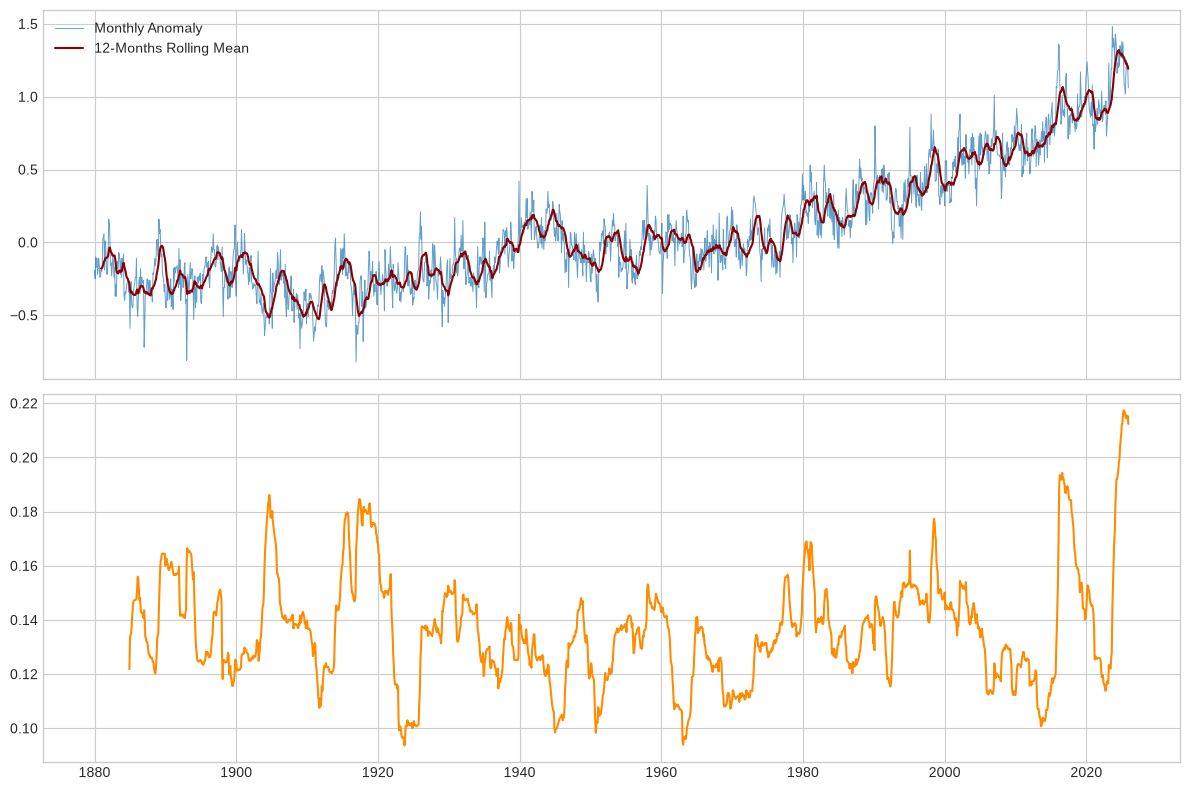

In [10]:
fig, axes = plt.subplots(2,1,figsize=(12,8), sharex=True)
axes[0].plot(series.index, series.values, lw=0.7, alpha=0.7, label='Monthly Anomaly')
axes[0].plot(series.index, series.rolling(12).mean(), color='darkred', lw=1.5, label='12-Months Rolling Mean')
axes[0].legend()
axes[1].plot(series.index, series.rolling(60).std(), color='darkorange')
plt.tight_layout()
plt.show()

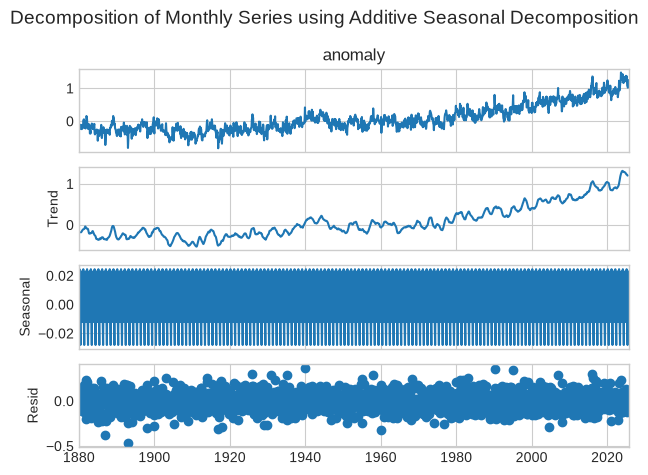

In [11]:
# Seasonal Analysis

sd_res = seasonal_decompose(series, model='additive', period=12)
sd_res.plot()

plt.suptitle("Decomposition of Monthly Series using Additive Seasonal Decomposition", fontsize=14)
plt.tight_layout()
plt.show()

#stl = STL(series, seasonal=)
#res = stl.fit()
#fig = res.plot()

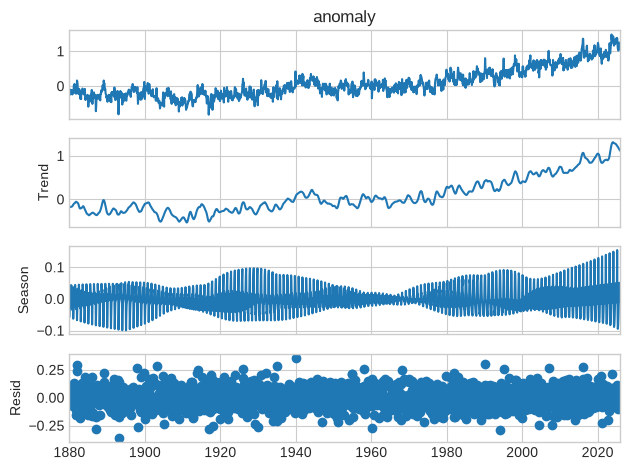

In [8]:
stl = STL(series, seasonal=31)
res = stl.fit()
fig = res.plot()